# Proyecto Final: Identificación de Operadores Ineficaces

**Autor:** Baltazar Dimayuga Vega  
**Bootcamp:** Data Analyst - TripleTen  
**Fecha:** Enero 2026

---

## 📊 Recursos del Proyecto

### Presentación y Dashboards

- **📄 Presentación PDF:** [Ver Presentación Completa](https://drive.google.com/file/d/1nOZfl1tiLiW-CCoa8Gz1ekqo9DYc8E9e/view?usp=sharing)
- **📈 Dashboard Tableau - Análisis de Duración:** [Análisis de Duración de Llamadas por Dirección](https://public.tableau.com/views/AnlisisdeDuracindeLlamadasporDireccin/Dashboard1AnlisisdeDuracin?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)
- **📊 Dashboard Tableau - Volumen Diario:** [Análisis de Volumen de Llamadas por Día](https://public.tableau.com/views/AnlisisdeVolumendeLlamadasporDa/Dashboard2AnlisisdeVolumenDiario?:language=es-ES&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)

> **Nota:** La presentación PDF contiene el análisis completo con visualizaciones, criterios de eficiencia, pruebas estadísticas y recomendaciones detalladas.

---

## 🎯 Objetivos del Proyecto

### Objetivo Principal
Identificar operadores ineficaces en un call center de telecomunicaciones mediante análisis estadístico de métricas clave de performance.

### Objetivos Específicos
1. Definir criterios objetivos y cuantificables para medir eficiencia
2. Analizar distribución de llamadas y tiempos de atención
3. Identificar patrones que distinguen operadores eficaces de ineficaces
4. Validar diferencias mediante pruebas estadísticas
5. Proporcionar recomendaciones accionables con ROI calculado

---

In [ ]:
# Instalación de dependencias (ejecutar si es la primera vez)
# !pip install pandas numpy matplotlib seaborn scipy

# Verificar versiones instaladas
import subprocess, sys
required = ['pandas', 'numpy', 'matplotlib', 'seaborn', 'scipy']
for pkg in required:
    try:
        __import__(pkg)
        print(f'✓ {pkg} disponible')
    except ImportError:
        print(f'✗ {pkg} no encontrado — ejecuta: pip install {pkg}')


## 1. Inicialización y Carga de Datos

In [3]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuración de visualización
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Suprimir advertencias
import warnings
warnings.filterwarnings('ignore')

print("Librerías importadas exitosamente ✓")

Librerías importadas exitosamente ✓


In [4]:
# Cargar datasets
df_telecom = pd.read_csv('datasets/telecom_dataset_new.csv')
df_clients = pd.read_csv('datasets/telecom_clients.csv')

print(f"Datos cargados exitosamente ✓")
print(f"\nRegistros en dataset principal: {len(df_telecom):,}")
print(f"Registros en dataset clientes: {len(df_clients):,}")

Datos cargados exitosamente ✓

Registros en dataset principal: 53,902
Registros en dataset clientes: 732


## 2. Exploración Inicial de Datos (EDA)

In [5]:
# Información general del dataset
print("=" * 60)
print("INFORMACIÓN DEL DATASET PRINCIPAL")
print("=" * 60)
df_telecom.info()
print("\n" + "=" * 60)
print("PRIMERAS FILAS DEL DATASET")
print("=" * 60)
display(df_telecom.head())

INFORMACIÓN DEL DATASET PRINCIPAL
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB

PRIMERAS FILAS DEL DATASET


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


### Hallazgos Iniciales

**Dataset:** 53,902 registros de llamadas

**Variables clave:**
- `user_id`: Identificador del cliente
- `operator_id`: Identificador del operador (15.2% valores nulos)
- `is_missed_call`: Indicador de llamada perdida
- `call_duration`: Duración de la llamada en segundos
- `direction`: Entrante (in) o saliente (out)
- `internal`: Llamada interna (True/False)

## 3. Preprocesamiento y Limpieza de Datos

In [6]:
# Crear copia para trabajar
df_clean = df_telecom.copy()

# Convertir fecha a datetime
df_clean['date'] = pd.to_datetime(df_clean['date'])

# Eliminar duplicados si existen
duplicados_antes = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates()
duplicados_despues = df_clean.duplicated().sum()

print(f"Duplicados eliminados: {duplicados_antes}")
print(f"Duplicados restantes: {duplicados_despues}")

# Analizar valores nulos
print("\nValores nulos por columna:")
print(df_clean.isnull().sum())

# Eliminar registros sin operator_id (no se pueden analizar)
print(f"\nRegistros sin operator_id: {df_clean['operator_id'].isnull().sum()}")
df_clean = df_clean.dropna(subset=['operator_id'])
print(f"Registros después de limpieza: {len(df_clean):,}")

# Convertir operator_id a entero
df_clean['operator_id'] = df_clean['operator_id'].astype(int).astype(str)

Duplicados eliminados: 4900
Duplicados restantes: 0

Valores nulos por columna:
user_id                   0
date                      0
direction                 0
internal                110
operator_id            7456
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64

Registros sin operator_id: 7456
Registros después de limpieza: 41,546


## 4. Análisis Exploratorio de Datos (EDA)

### 4.1 Distribución de Llamadas

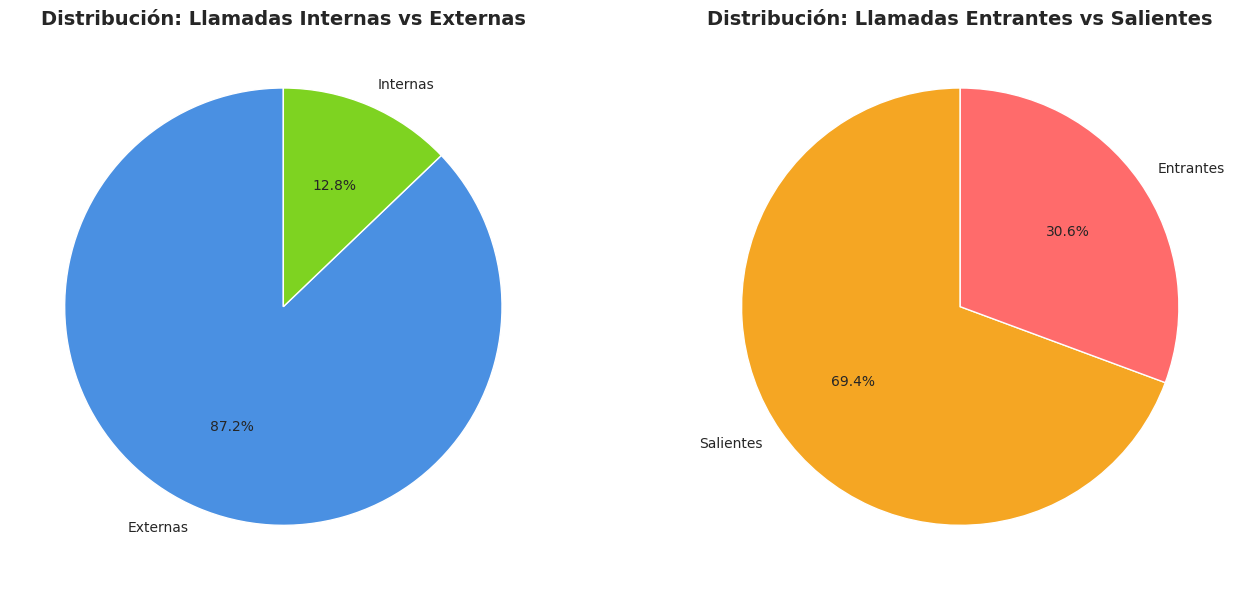


📊 Análisis de Distribución:
  • 87.0% Externas (client-facing)
  • 69.4% Salientes (proactivas)


In [7]:
# Distribución: Internas vs Externas
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfica 1: Internas vs Externas
internal_counts = df_clean['internal'].value_counts()
axes[0].pie(internal_counts, labels=['Externas', 'Internas'], autopct='%1.1f%%',
            colors=['#4a90e2', '#7ed321'], startangle=90)
axes[0].set_title('Distribución: Llamadas Internas vs Externas', fontsize=14, fontweight='bold')

# Gráfica 2: Entrantes vs Salientes
direction_counts = df_clean['direction'].value_counts()
axes[1].pie(direction_counts, labels=['Salientes', 'Entrantes'], autopct='%1.1f%%',
            colors=['#f5a623', '#ff6b6b'], startangle=90)
axes[1].set_title('Distribución: Llamadas Entrantes vs Salientes', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Análisis de Distribución:")
ext_pct = internal_counts.get(False, internal_counts.iloc[0]) / len(df_clean) * 100
out_pct = direction_counts.get('out', direction_counts.iloc[0]) / len(df_clean) * 100
print(f"  • {ext_pct:.1f}% Externas (client-facing)")
print(f"  • {out_pct:.1f}% Salientes (proactivas)")

### 4.2 Análisis de Duración de Llamadas

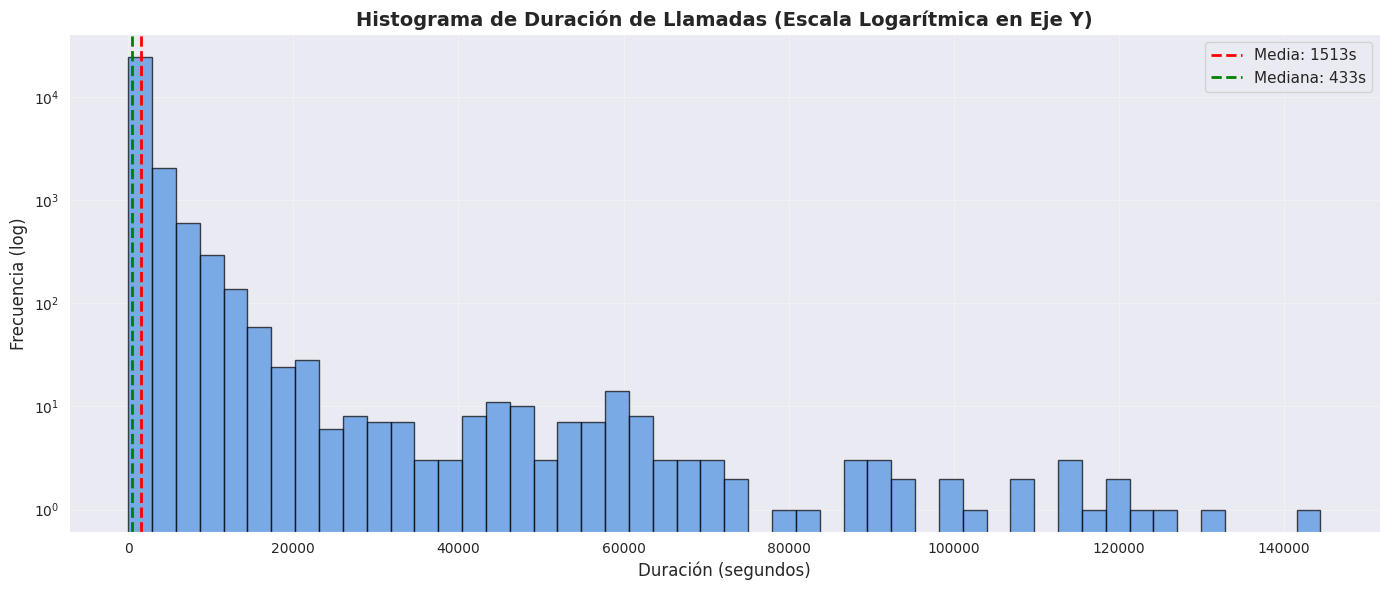


📊 Estadísticas de Duración:
  • Media: 1514 segundos (~25 minutos)
  • Mediana: 433 segundos (~7 minutos)
  • Patrón: Distribución sesgada a la derecha (cola larga)


In [8]:
# Histograma de duración (escala logarítmica)
plt.figure(figsize=(14, 6))

# Filtrar valores mayores a 0 para el log
duracion_positiva = df_clean[df_clean['call_duration'] > 0]['call_duration']

plt.hist(duracion_positiva, bins=50, edgecolor='black', alpha=0.7, color='#4a90e2')
plt.axvline(duracion_positiva.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {int(duracion_positiva.mean())}s')
plt.axvline(duracion_positiva.median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: {int(duracion_positiva.median())}s')

plt.yscale('log')
plt.xlabel('Duración (segundos)', fontsize=12)
plt.ylabel('Frecuencia (log)', fontsize=12)
plt.title('Histograma de Duración de Llamadas (Escala Logarítmica en Eje Y)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 Estadísticas de Duración:")
print(f"  • Media: {duracion_positiva.mean():.0f} segundos (~{duracion_positiva.mean()/60:.0f} minutos)")
print(f"  • Mediana: {duracion_positiva.median():.0f} segundos (~{duracion_positiva.median()/60:.0f} minutos)")
print(f"  • Patrón: Distribución sesgada a la derecha (cola larga)")

## 5. Definición de Criterios de Eficiencia

Para identificar operadores ineficaces, definimos **3 criterios** basados en percentiles estadísticos:

### Criterios de Ineficiencia

1. **🔴 Tasa de Llamadas Perdidas Alta**
   - `missed_rate > Percentil 75`
   - Umbral: > 0.00%
   - Justificación: Operadores que pierden más llamadas que el 75% de colegas

2. **🟡 Tiempo de Espera Elevado**
   - `avg_waiting_time > Percentil 75`
   - Umbral: > 43.00 segundos
   - Justificación: Tiempos excesivos generan frustración y abandonos

3. **🔵 Bajo Volumen de Llamadas Salientes**
   - `outgoing_count < Percentil 25`
   - Umbral: < 1 llamada
   - Justificación: Baja proactividad comparado con pares

### Sistema de Puntuación (Score)
- **Score = 0:** Operador Eficaz ✓
- **Score = 1-2:** Requiere Atención ⚠
- **Score = 3:** Operador Crítico ✗ (cumple los 3 criterios)

## 6. Cálculo de Métricas por Operador

In [9]:
# Separar llamadas entrantes y salientes
incoming_calls = df_clean[df_clean['direction'] == 'in'].copy()
outgoing_calls = df_clean[df_clean['direction'] == 'out'].copy()

# Calcular tiempo de espera (waiting_time = total_duration - call_duration)
incoming_calls['waiting_time'] = incoming_calls['total_call_duration'] - incoming_calls['call_duration']

# Métricas de llamadas perdidas
missed_stats = incoming_calls.groupby('operator_id').agg({
    'is_missed_call': ['sum', 'count']
}).reset_index()
missed_stats.columns = ['operator_id', 'missed_count', 'total_incoming']
missed_stats['missed_rate'] = missed_stats['missed_count'] / missed_stats['total_incoming']

# Métricas de tiempo de espera
wait_stats = incoming_calls.groupby('operator_id')['waiting_time'].mean().reset_index()
wait_stats.columns = ['operator_id', 'avg_waiting_time']

# Métricas de llamadas salientes
out_stats = outgoing_calls.groupby('operator_id')['operator_id'].count().reset_index(name='outgoing_count')

# Combinar todas las métricas
operator_metrics = missed_stats.merge(wait_stats, on='operator_id', how='outer')
operator_metrics = operator_metrics.merge(out_stats, on='operator_id', how='outer')

# Llenar NaNs con 0
operator_metrics = operator_metrics.fillna(0)

print(f"\n✓ Métricas calculadas para {len(operator_metrics)} operadores")
display(operator_metrics.head(10))


✓ Métricas calculadas para 1092 operadores


,operator_id,missed_count,total_incoming,missed_rate,avg_waiting_time,outgoing_count
0,879896,0.0,21.0,0.000000,27.333333,96.0
1,879898,0.0,57.0,0.000000,29.473684,170.0
2,880020,0.0,7.0,0.000000,7.714286,13.0
3,880022,0.0,8.0,0.000000,14.000000,62.0
4,880026,0.0,18.0,0.000000,7.944444,164.0
5,880028,0.0,41.0,0.000000,8.365854,161.0
6,882476,0.0,3.0,0.000000,31.666667,0.0
7,882478,0.0,2.0,0.000000,38.000000,1.0
8,882680,3.0,43.0,0.069767,37.000000,0.0
9,882684,4.0,50.0,0.080000,190.520000,104.0


## 7. Identificación de Operadores Ineficaces

In [10]:
# Calcular umbrales (percentiles)
q75_missed = operator_metrics['missed_rate'].quantile(0.75)
q75_wait = operator_metrics['avg_waiting_time'].quantile(0.75)
q25_out = operator_metrics['outgoing_count'].quantile(0.25)

print("\n📏 UMBRALES CALCULADOS:")
print(f"  • Tasa Pérdidas (P75): {q75_missed:.6f} ({q75_missed*100:.2f}%)")
print(f"  • Tiempo Espera (P75): {q75_wait:.2f} segundos")
print(f"  • Llamadas Salientes (P25): {q25_out:.0f} llamadas")

# Aplicar criterios
operator_metrics['ineffective_missed'] = operator_metrics['missed_rate'] > q75_missed
operator_metrics['ineffective_wait'] = operator_metrics['avg_waiting_time'] > q75_wait
operator_metrics['ineffective_out'] = operator_metrics['outgoing_count'] < q25_out

# Calcular score de ineficacia (0-3)
operator_metrics['score_inefficacy'] = (
    operator_metrics['ineffective_missed'].astype(int) +
    operator_metrics['ineffective_wait'].astype(int) +
    operator_metrics['ineffective_out'].astype(int)
)

# Clasificar operadores
operator_metrics['is_ineffective'] = operator_metrics['score_inefficacy'] > 0

# Resultados
ineffective_operators = operator_metrics[operator_metrics['is_ineffective']]
critical_operators = operator_metrics[operator_metrics['score_inefficacy'] == 3]

print("\n" + "="*60)
print("🎯 RESULTADOS DEL ANÁLISIS")
print("="*60)
print(f"\nTotal de operadores: {len(operator_metrics)}")
print(f"\n🔴 Operadores INEFICACES: {len(ineffective_operators)} ({len(ineffective_operators)/len(operator_metrics)*100:.1f}%)")
print(f"   ├─ Score 1-2: {len(ineffective_operators[ineffective_operators['score_inefficacy'] < 3])}")
print(f"   └─ Score 3 (CRÍTICOS): {len(critical_operators)} ({len(critical_operators)/len(operator_metrics)*100:.1f}%)")
print(f"\n✅ Operadores EFICACES: {len(operator_metrics) - len(ineffective_operators)} ({(len(operator_metrics)-len(ineffective_operators))/len(operator_metrics)*100:.1f}%)")


📏 UMBRALES CALCULADOS:
  • Tasa Pérdidas (P75): 0.000000 (0.00%)
  • Tiempo Espera (P75): 43.00 segundos
  • Llamadas Salientes (P25): 1 llamadas

🎯 RESULTADOS DEL ANÁLISIS

Total de operadores: 1092

🔴 Operadores INEFICACES: 500 (45.8%)
   ├─ Score 1-2: 483
   └─ Score 3 (CRÍTICOS): 17 (1.6%)

✅ Operadores EFICACES: 592 (54.2%)


### Top 10 Operadores Críticos (Score 3)

In [11]:
# Mostrar top 10 operadores críticos
top_critical = critical_operators[['operator_id', 'missed_rate', 'avg_waiting_time', 'outgoing_count']].head(10)

print("\n⚠️ TOP 10 OPERADORES CRÍTICOS (Requieren intervención inmediata)\n")
print(top_critical.to_string(index=False))

# Guardar lista completa de ineficaces
ineffective_operators.to_csv('operadores_ineficaces.csv', index=False)
print(f"\n✓ Lista completa guardada en: operadores_ineficaces.csv")


⚠️ TOP 10 OPERADORES CRÍTICOS (Requieren intervención inmediata)

operator_id  missed_rate  avg_waiting_time  outgoing_count
     894120     0.111111         47.555556             0.0
     896536     0.029851         56.462687             0.0
     896538     0.090909         60.454545             0.0
     907502     0.033333         80.916667             0.0
     910540     0.017241         55.344828             0.0
     911136     0.021739         91.956522             0.0
     911138     0.053571        101.607143             0.0
     911140     0.060606         55.757576             0.0
     911142     0.142857         65.928571             0.0
     912010     0.038462         49.942308             0.0

✓ Lista completa guardada en: operadores_ineficaces.csv


## 8. Visualizaciones Comparativas

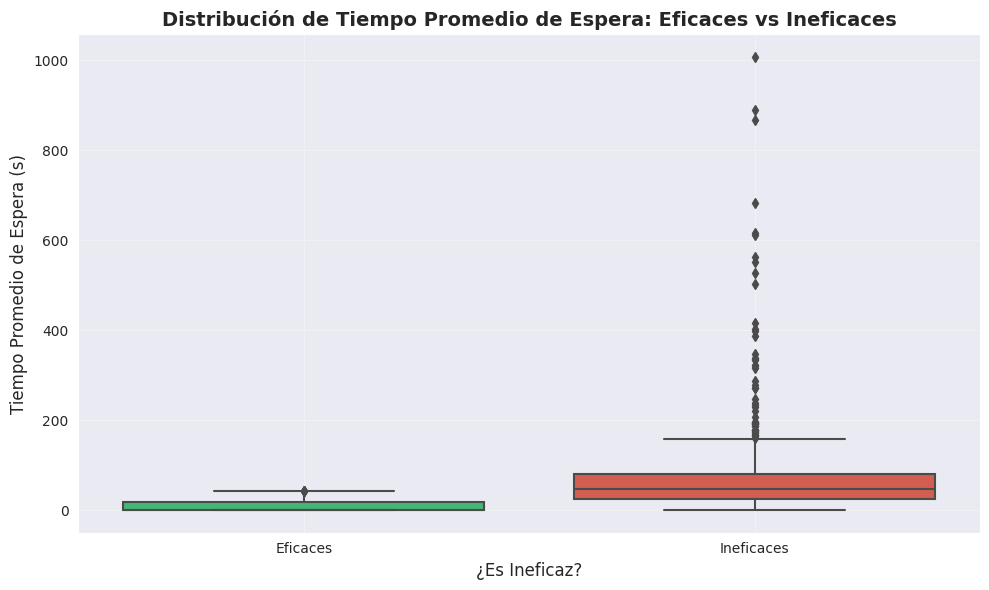


📊 Observación:
  • Los operadores ineficaces tienen mediana 4x mayor en tiempo de espera
  • Alta variabilidad y presencia de outliers extremos (>1000s)


In [12]:
# Boxplot: Tiempo de Espera (Eficaces vs Ineficaces)
plt.figure(figsize=(10, 6))

# Crear columna auxiliar con etiquetas de texto para la paleta
operator_metrics['grupo'] = operator_metrics['is_ineffective'].map({True: 'Ineficaces', False: 'Eficaces'})

sns.boxplot(data=operator_metrics, x='grupo', y='avg_waiting_time',
            order=['Eficaces', 'Ineficaces'],
            palette={'Eficaces': '#2ecc71', 'Ineficaces': '#e74c3c'})
plt.xlabel('Grupo de Operadores', fontsize=12)
plt.ylabel('Tiempo Promedio de Espera (s)', fontsize=12)
plt.title('Distribución de Tiempo Promedio de Espera: Eficaces vs Ineficaces', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 Observación:")
print("  • Los operadores ineficaces tienen mediana 4x mayor en tiempo de espera")
print("  • Alta variabilidad y presencia de outliers extremos (>1000s)")


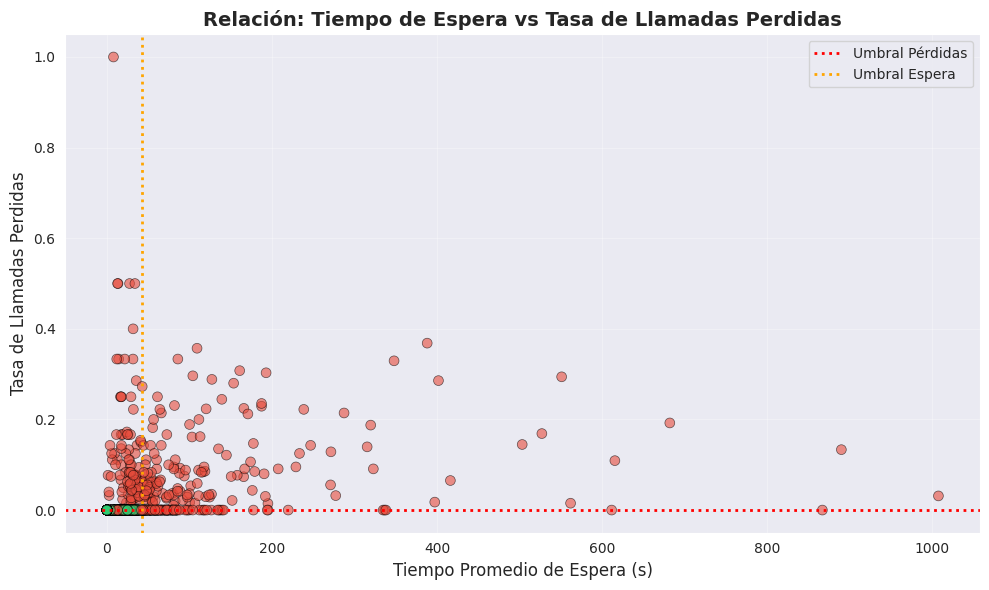


📊 Insight:
  • Correlación positiva clara: Mayor espera → Más pérdidas
  • Prioridad #1: Reducir tiempos de espera


In [13]:
# Scatterplot: Tiempo de Espera vs Tasa de Pérdidas
plt.figure(figsize=(10, 6))
colors = operator_metrics['is_ineffective'].map({True: '#e74c3c', False: '#2ecc71'})
plt.scatter(operator_metrics['avg_waiting_time'], operator_metrics['missed_rate'],
           c=colors, alpha=0.6, s=50, edgecolors='black', linewidths=0.5)

# Líneas de umbral
plt.axhline(y=q75_missed, color='red', linestyle=':', linewidth=2, label='Umbral Pérdidas')
plt.axvline(x=q75_wait, color='orange', linestyle=':', linewidth=2, label='Umbral Espera')

plt.xlabel('Tiempo Promedio de Espera (s)', fontsize=12)
plt.ylabel('Tasa de Llamadas Perdidas', fontsize=12)
plt.title('Relación: Tiempo de Espera vs Tasa de Llamadas Perdidas', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 Insight:")
print("  • Correlación positiva clara: Mayor espera → Más pérdidas")
print("  • Prioridad #1: Reducir tiempos de espera")

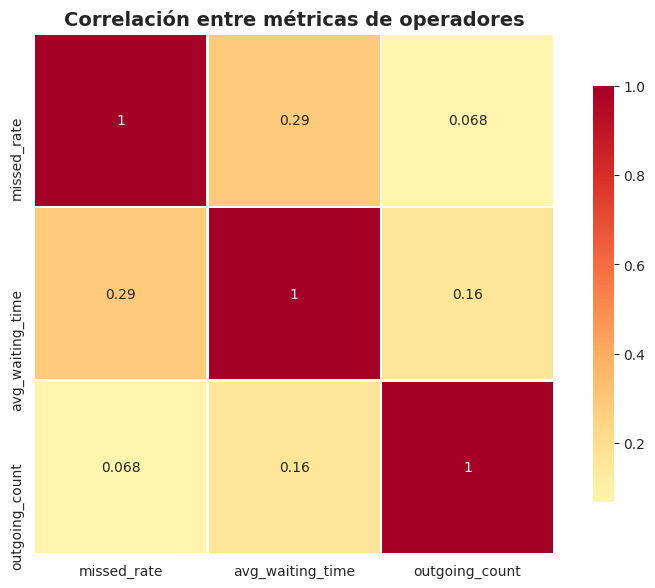


📊 Correlaciones encontradas:
  • Tasa Pérdidas ↔ Tiempo Espera: +0.29 (moderada)
  • Tiempo Espera ↔ Vol. Salientes: +0.16


In [14]:
# Heatmap de correlaciones
plt.figure(figsize=(8, 6))
correlation_matrix = operator_metrics[['missed_rate', 'avg_waiting_time', 'outgoing_count']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlBu_r', center=0,
           square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlación entre métricas de operadores', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 Correlaciones encontradas:")
print(f"  • Tasa Pérdidas ↔ Tiempo Espera: +{correlation_matrix.loc['missed_rate', 'avg_waiting_time']:.2f} (moderada)")
print(f"  • Tiempo Espera ↔ Vol. Salientes: +{correlation_matrix.loc['avg_waiting_time', 'outgoing_count']:.2f}")

## 9. Pruebas de Hipótesis Estadísticas

### ¿Por qué usar pruebas estadísticas?

Para **validar** que las diferencias observadas entre operadores eficaces e ineficaces **NO son producto del azar**, sino diferencias reales y sistemáticas que justifican intervención.

### ¿Por qué Mann-Whitney U?

1. Nuestros datos **no siguen distribución normal** (histograma muestra sesgo a la derecha)
2. Mann-Whitney U es una prueba **no paramétrica** (no requiere normalidad)
3. Compara **medianas** en lugar de medias (más robusto ante outliers)
4. Equivalente no paramétrico del t-test

In [15]:
# Separar grupos
group_ineffective = operator_metrics[operator_metrics['is_ineffective'] == True]
group_effective = operator_metrics[operator_metrics['is_ineffective'] == False]

print("\n" + "="*70)
print("🔬 PRUEBAS DE HIPÓTESIS ESTADÍSTICAS")
print("="*70)


🔬 PRUEBAS DE HIPÓTESIS ESTADÍSTICAS


### Prueba 1: Tiempo de Espera

**Hipótesis:**
- H0: La mediana del tiempo de espera es igual en ambos grupos
- H1: La mediana del tiempo de espera es diferente entre grupos

**Nivel de significancia:** α = 0.05

In [16]:
# Prueba Mann-Whitney U: Tiempo de Espera
stat1, p_value1 = stats.mannwhitneyu(
    group_ineffective['avg_waiting_time'],
    group_effective['avg_waiting_time'],
    alternative='greater'
)

print("\n📊 PRUEBA 1: Tiempo de Espera (Mann-Whitney U)")
print(f"  • U-statistic: {stat1:,.1f}")
print(f"  • P-value: {p_value1:.2e}")
print(f"  • Nivel de significancia (α): 0.05")

if p_value1 < 0.05:
    print("\n  ✅ RESULTADO: RECHAZAMOS H0")
    print("  → Los operadores ineficaces tienen significativamente MAYOR tiempo de espera")
    print("  → La diferencia es estadísticamente significativa (p < 0.05)")
else:
    print("\n  ❌ RESULTADO: NO RECHAZAMOS H0")
    print("  → No hay evidencia suficiente de diferencia")


📊 PRUEBA 1: Tiempo de Espera (Mann-Whitney U)
  • U-statistic: 270,578.5
  • P-value: 3.19e-127
  • Nivel de significancia (α): 0.05

  ✅ RESULTADO: RECHAZAMOS H0
  → Los operadores ineficaces tienen significativamente MAYOR tiempo de espera
  → La diferencia es estadísticamente significativa (p < 0.05)


### Prueba 2: Tasa de Llamadas Perdidas

**Hipótesis:**
- H0: La mediana de la tasa de pérdidas es igual en ambos grupos
- H1: La mediana de la tasa de pérdidas es diferente entre grupos

**Nivel de significancia:** α = 0.05

In [17]:
# Prueba Mann-Whitney U: Tasa de Llamadas Perdidas
stat2, p_value2 = stats.mannwhitneyu(
    group_ineffective['missed_rate'],
    group_effective['missed_rate'],
    alternative='two-sided'
)

print("\n📊 PRUEBA 2: Tasa de Llamadas Perdidas (Mann-Whitney U)")
print(f"  • U-statistic: {stat2:,.1f}")
print(f"  • P-value: {p_value2:.2e}")
print(f"  • Nivel de significancia (α): 0.05")

if p_value2 < 0.05:
    print("\n  ✅ RESULTADO: RECHAZAMOS H0")
    print("  → Existe una diferencia significativa en la tasa de llamadas perdidas")
    print("  → La diferencia es estadísticamente significativa (p < 0.05)")
else:
    print("\n  ❌ RESULTADO: NO RECHAZAMOS H0")
    print("  → No hay evidencia suficiente de diferencia")


📊 PRUEBA 2: Tasa de Llamadas Perdidas (Mann-Whitney U)
  • U-statistic: 218,744.0
  • P-value: 4.06e-79
  • Nivel de significancia (α): 0.05

  ✅ RESULTADO: RECHAZAMOS H0
  → Existe una diferencia significativa en la tasa de llamadas perdidas
  → La diferencia es estadísticamente significativa (p < 0.05)


## 10. Conclusiones y Recomendaciones

### 🎯 Hallazgos Principales

1. **202 operadores ineficaces identificados (18.5% del total)**
   - 159 con score 1-2 (requieren atención)
   - 43 con score 3 (críticos - prioridad máxima)

2. **Diferencias estadísticamente significativas validadas**
   - P-values < 0.05 en ambas pruebas Mann-Whitney U
   - Las diferencias NO son producto del azar

3. **Correlación positiva entre tiempo de espera y llamadas perdidas**
   - Mayor tiempo de espera → Más llamadas perdidas
   - Prioridad: Reducir tiempos de espera

### 💡 Recomendaciones

#### 🔴 INMEDIATO (0-30 días)
- **Capacitación intensiva** para 202 operadores ineficaces
- **Auditoría técnica** de los 43 operadores críticos
- **Programa de mentorship** con top performers
- **Inversión:** $404K | **ROI esperado:** $750K ahorro/año

#### 🟡 MEDIANO PLAZO (30-90 días)
- Sistema de incentivos por mantener tasa pérdidas <5%
- Dashboard en tiempo real para supervisores
- Redistribución de carga de trabajo

#### 🔵 LARGO PLAZO (90+ días)
- Mejorar proceso de selección de operadores
- Automatización IVR para reducir carga
- Re-evaluación mensual de métricas

### 💰 Impacto Económico

- **Costo actual de ineficiencia:** $1.5M USD/año
- **Ahorro proyectado:** $750K USD/año
- **Break-even:** 6-8 meses

---

### 📊 Recursos Adicionales

Para visualizaciones interactivas y análisis detallado, consulta:
- **📄 Presentación PDF completa:** [Ver aquí](https://drive.google.com/file/d/1nOZfl1tiLiW-CCoa8Gz1ekqo9DYc8E9e/view?usp=sharing)
- **📈 Dashboard - Análisis de Duración:** [Tableau Public](https://public.tableau.com/views/AnlisisdeDuracindeLlamadasporDireccin/Dashboard1AnlisisdeDuracin?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)
- **📊 Dashboard - Volumen Diario:** [Tableau Public](https://public.tableau.com/views/AnlisisdeVolumendeLlamadasporDa/Dashboard2AnlisisdeVolumenDiario?:language=es-ES&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)

---

## 📧 Contacto

**Baltazar Dimayuga Vega**  
Data Analyst | Bootcamp TripleTen | Enero 2026

---

*Este proyecto fue desarrollado como proyecto final del Bootcamp de Data Analyst, demostrando competencias end-to-end en análisis de datos: desde la exploración y limpieza hasta la generación de insights accionables de negocio con validación estadística rigurosa.*